In [1]:
import numpy as np
import sisl
from sisl.viz.processors.math import normalize
from utils.loader import load_datastructure, path_finder, parse_lwc
from utils.plots import mark_electrode
from utils.structure import find_nearest_atoms

from ipywidgets import interact


In [2]:

SCALE = 0.6
OFFSET = 0.1
def plot_pdos_old(lwc):
    PARAMS = "{}L_{}W_{}C".format(*lwc)
    # extract data
    DATA = np.load(f"../notebooks/calculations/device_ldos_{PARAMS}.npz")
    ldos, lr_idx = DATA["ldos"], DATA["lr_idx"]
    # build device
    device = sisl.io.get_sile(f"../notebooks/structures/device_{PARAMS}.xyz").read_geometry()
    # scale pdos for plotting
    norm_pdos_avg_E = normalize(ldos.mean(axis=(0,1)))*0.6 + 0.1
    style = mark_electrode(lr_idx)
    style.append({"size": norm_pdos_avg_E})
    return device.plot(axes="xy", atoms_style=style)

In [3]:
def show_ldos_pdos_old(LWC):

    project_dir = path_finder("QTM")
    results_dir = project_dir / "results"
    notebook_dir = project_dir / "notebooks"
    atol = 0.01
    l, w, c = LWC
    _params_ = f"{l}L_{w}W_{c}C"
    # load data
    data = np.load(notebook_dir / f"calculations/device_ldos_{_params_}.npz")
    device = sisl.io.get_sile(notebook_dir / f"structures/device_{_params_}.xyz").read_geometry()
    site = find_nearest_atoms(device.xyz, device.center(), 1)
    ldos, lr_idx = data["ldos"], data["lr_idx"]
    ldos_center = ldos[0, :, site]
    energies = data["energies"]
    norm_pdos_avg_E = normalize(ldos.mean(axis=(0,1)),0, 3) 
    bg_idxs = np.argwhere(normalize(ldos_center) < atol)
    bgmin = min(energies[bg_idxs])
    bgmax = max(energies[bg_idxs])    
    style = mark_electrode(lr_idx)
    style.append({"size": norm_pdos_avg_E})
    
    # 1. Generate the initial sisl plot (Spatial)
    fig = device.plot(axes="xy", atoms_style=style, backend="matplotlib")
    # 2. Resize the figure to be wider to accommodate two plots
    fig.set_size_inches(12, 6)
    
    # 3. Adjust the existing sisl axis to occupy only the left half
    # The first axis is usually fig.axes[0]
    ax_spatial = fig.gca()
    ax_spatial.set_position([0.05, 0.15, 0.4, 0.75])
    
    # 4. Add the new LDOS energy axis
    ax_energy = fig.add_axes([0.55, 0.15, 0.4, 0.75])
    ax_energy.plot(ldos_center, energies, color='blue')
    ax_energy.axhline(y=bgmin, color='red', linestyle='--', label='BG Min/Max')
    ax_energy.axhline(y=bgmax, color='red', linestyle='--')
    ax_energy.axvline(x=0, color='black', linestyle='--')
    ax_energy.set_title("LDOS vs Energy", fontsize=16)
    ax_energy.set_xlabel("LDOS (a.u.)", fontsize=14)
    ax_energy.set_ylabel("$E - E_f$ (eV)", fontsize=14)
    ax_energy.tick_params(axis='both', which='major', labelsize=10)
    
    # Apply sizes to Spatial Axis
    ax_spatial.tick_params(axis='both', which='major', labelsize=10)
    ax_spatial.set_xlabel(ax_spatial.get_xlabel(), fontsize=14)
    ax_spatial.set_ylabel(ax_spatial.get_ylabel(), fontsize=14)
    
    
    fig.suptitle(f"LDOS for LWC = {LWC}", fontsize=20)
    

In [4]:
def show_modulation(LWC, C):
    electrode, ribbon, device, data = load_datastructure(LWC)
    site = find_nearest_atoms(device.xyz, device.center(), 1)
    ldos = data[f"ldos_{C}" if C!="C0" else "ldos"]
    ldos_center = ldos[0, :, site]
    lr_idx = data["lr_idx"]
    energies = data["energies"]
    bgmin = data[f"bgmin_{C}"]
    bgmax = data[f"bgmax_{C}"]
    norm_pdos_avg_E = normalize(data["ldos"].mean(axis=(0,1)),0, 3)
    style = mark_electrode(lr_idx)
    style.append({"size": norm_pdos_avg_E})
    
    
    
    # 1. Generate the initial sisl plot (Spatial)
    fig = device.plot(axes="xy", backend="matplotlib", atoms_style=style)
    fig.suptitle(f"LWC = {LWC} with" + " {} ".format(C if C!="C0" else "no") + "modulation", fontsize=20)
    
    # 2. Resize the figure to be wider to accommodate two plots
    fig.set_size_inches(12, 6)
    
    # 3. Adjust the existing sisl axis to occupy only the left half
    # The first axis is usually fig.axes[0]
    ax_spatial = fig.gca()
    ax_spatial.set_position([0.05, 0.15, 0.4, 0.75])
    
    
    # 4. Add the new LDOS energy axis
    ax_energy = fig.add_axes([0.55, 0.15, 0.4, 0.75])
    ax_energy.scatter(ldos_center, energies, color='blue')
    ax_energy.axhline(y=bgmin, color='red', linestyle='--', label='BG Min/Max')
    ax_energy.axhline(y=bgmax, color='red', linestyle='--')
    ax_energy.axvline(x=0, color='black', linestyle='--')
    ax_energy.set_title("LDOS vs Energy", fontsize=16)
    ax_energy.set_xlabel("LDOS (a.u.)", fontsize=14)
    ax_energy.set_ylabel("$E - E_f$ (eV)", fontsize=14)
    ax_energy.tick_params(axis='both', which='major', labelsize=10)
    
    # Apply sizes to Spatial Axis
    ax_spatial.tick_params(axis='both', which='major', labelsize=10)
    ax_spatial.set_xlabel(ax_spatial.get_xlabel(), fontsize=14)
    ax_spatial.set_ylabel(ax_spatial.get_ylabel(), fontsize=14)
    
    

# Creation of reduced structure

**Workflow: Nanoribbon**
1. Create electrode: `build_electrode(w, l)`
    * width : number of atoms in *y* (image: 9)
    * length : how many *armchair* in *x* (image: 2)
2. Create center region: `build_nanoribbon(electrode, c)`
    * `electrode`: sisl object
    * center size : how many `electrodes` to use for center region.
    * automatically adds the left/right electrodes

<img src="ribbon_creation.png" width="800">



**Workflow: Reduced device** `build_reduced_device(ribbon, repeat=3)`

3. Change `electrode` atoms
    * left and right has different atoms
4. Copy structure, rotate around center and add to final structure
    * Repeat 3 times for angles : $\{0^\circ,\ \pm 60^\circ\}$ 

<img src="add_arms.png" width="800">

5. Remove atoms overlapping
    * If atoms has same position (tolerance: $0.1$ Å)
6. Save atom indecies for electrodes (left: N, right: O)
7. Change all atoms to C


## Compatibility issues with $w,\ l,\ c$
**Case**: Center size too small -- uncomment line 9

In [5]:
# using '__' to avoid overwriting the compatible parameters
from utils.structure import build_electrode, build_nanoribbon, build_reduced_device
from utils.plots import mark_electrode
w, l, c = 13, 2, 2
e = build_electrode(w, l)
r = build_nanoribbon(e, c)
d, lr_idx = build_reduced_device(r, e, repeat=3)
atoms_style = []
# atoms_style = mark_electrode(lr_idx) # uncomment to mark electrodes
d.plot(axes="xy", atoms_style=atoms_style) # plot device in xy plane

       Initial number of atoms: 624
 Atoms after removing overlaps: 372


## Infer dimensions

**Ribbon**: Geometric center close to high symmetry point (carbon ring center) $W = 5+4i$  
* If $W < 5$ geometric center is (likely) on a dimer.  
* Center region has to satisfy : $2(i+1) = 0 \mod{L}\rightarrow C = \frac{2(i+1)}{L}$
* Spacing between valid $i$: $s = \frac{L}{\gcd{(2,L)}}$  
* Lowest valid: $T = -1 \mod{s}$  
* Given $i'$ the next valid is $i = i' + (T-i')\mod{s}$  
Implemented in `utils.infer_centersize(l,i)`

In [6]:
from utils import build_electrode, build_nanoribbon, infer_centersize
from utils.plots import plot_with_center, mark_electrode
l, i = 2, 5
l, w, c = infer_centersize(l, i)
# l,w,c = 2, 5, 2 --- IGNORE ---
print(f"Length: {l}, Width: {w}, Center size: {c}")

e = build_electrode(w, l) # width, length
r = build_nanoribbon(e, c) # electrode, center_size
d,lr_idxs = build_reduced_device(r, e, repeat=3) # device, electrode, amount of rotations
plot_with_center(r)

Length: 2, Width: 25, Center size: 6
       Initial number of atoms: 2400
 Atoms after removing overlaps: 1464


In [7]:
a_style = mark_electrode((lr_idxs))
plot_with_center(d, atoms_style=a_style)

### Why does 'compatible' dimensions matter?


#### The bad case
Edge states in center region

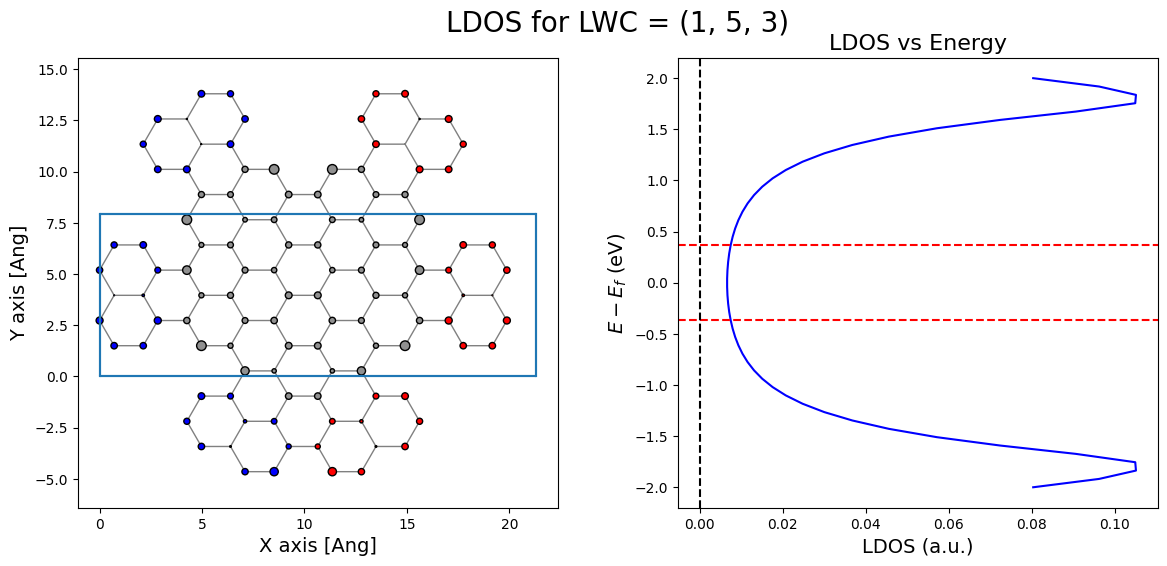

In [8]:
lwc = 1, 5, 3
show_ldos_pdos_old(lwc)

### If we choose *LWC* compatible

Still edge states in electrodes

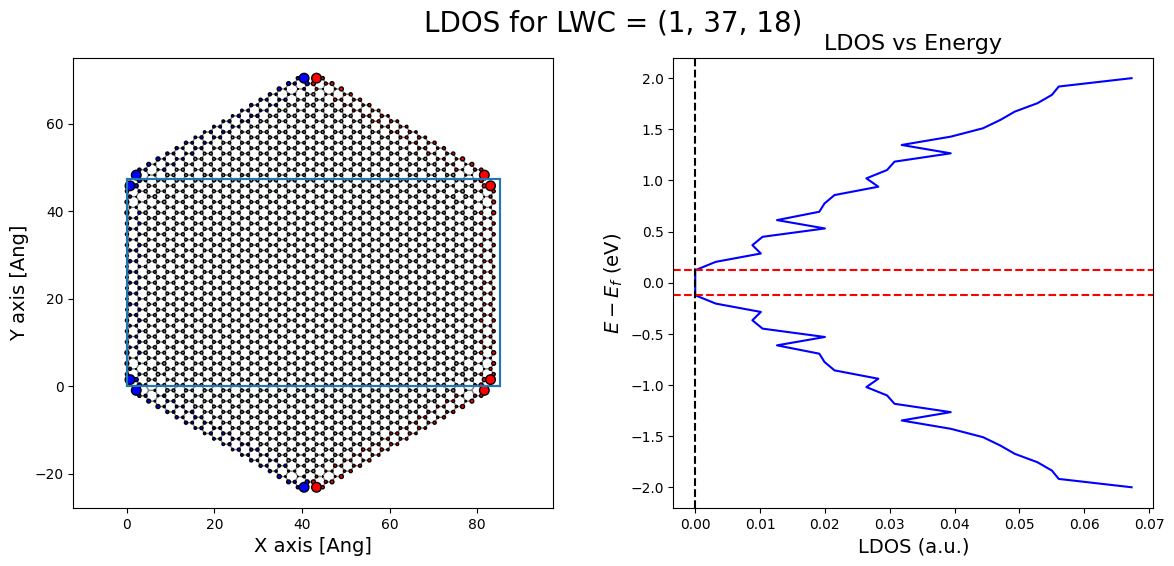

In [9]:
lwc = infer_centersize(1, i=6)
lwc = 1,37,18
show_ldos_pdos_old(lwc)

### Does electrode length remove edge states?

(3, 13, 2)


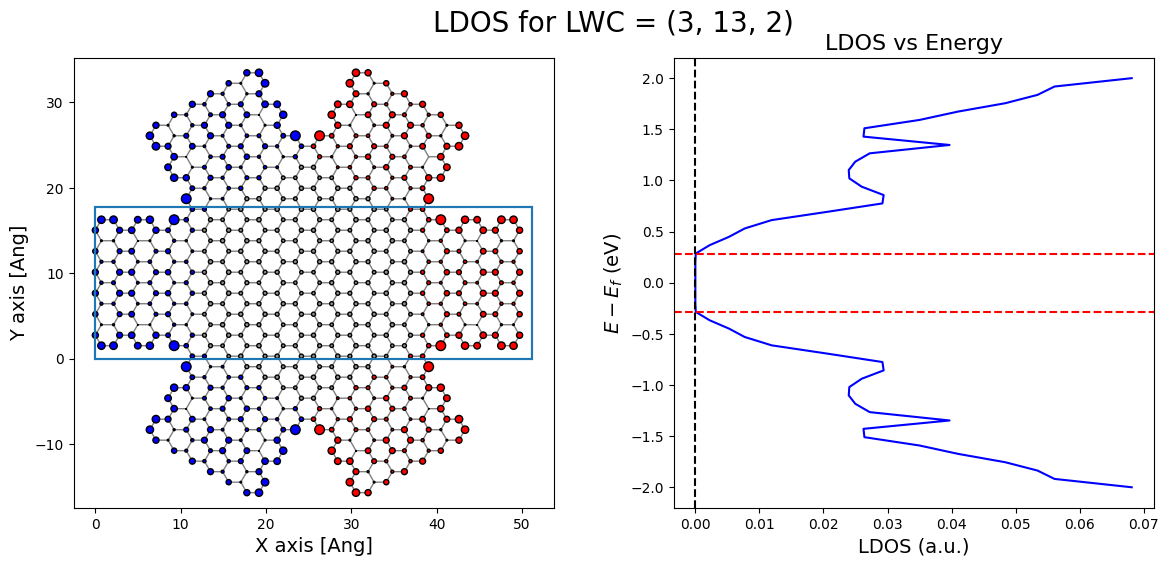

In [10]:
lwc = infer_centersize(3, i=2)
print(lwc)
show_ldos_pdos_old(lwc)

## What if we modulate the self-energies

In [11]:
results_dir = path_finder("QTM") / "results"
lwc_list = [parse_lwc(f) for f in sorted(results_dir.glob("L*_W*_C*"))]
modulations = np.unique([str(m.split("_")[1]) for m in load_datastructure(lwc_list[0])[-1].keys() if m.startswith("bg")]).tolist()
valid_idxs = [i for i, lwc in enumerate(lwc_list) if load_datastructure(lwc)[-1]["ldos"].shape[-1]>6]
valid_lwcs = [lwc_list[i] for i in valid_idxs]

interact(show_modulation,LWC=valid_lwcs, C=modulations); 

interactive(children=(Dropdown(description='LWC', options=((1, 5, 2), (1, 9, 4), (1, 13, 6), (1, 17, 8), (1, 2…

## How does changing modulation and size affect the LDOS?
<img src="bg_vs_R_W.png" width=800>

# Code deep-dive

The amount of functions and methods make it hard to show everything completely, so here are some highlights for what was difficult and some cool quality of life implementations. Finally some insights into the algorithms

## What is the bottleneck?
Running the script for computing LDOS for 5 different $C$ & W > 33 : ~ 1.5 hours...  
**Inverse**: Taking the inverse of a $2000 \times 2000$ $G^{(-1)}$ is not efficient
* Idea: LDOS only concerned with diagonal of Greens function: $G_{ii}$
* LU factorization and sparse matricies
* Further: *'batching'* the calculations to reduce computation time (not yet realized)

But what does the computer tell us is the slowest process?

In [12]:
%load_ext line_profiler
from utils import load_datastructure, multi_LDOS, lr_energies

In [13]:
i = -1
electrode, ribbon, device, data = load_datastructure(lwc_list[i]); lwc_list[i]
device.na

2328

In [15]:
lprun_args = dict(device=device, 
                  electrode=electrode, 
                  energies=np.linspace(-2, 2, num=2),
                  lr_indices=data["lr_idx"],
                  Nk=1,
                  form="csc",
                  eta=1e-5,
                  modulate_SE=None,
                  LDOS_E0=None,
                #   sites=None
                  sites=find_nearest_atoms(device.xyz, device.center(), neighbours=6)
)
%lprun -f multi_LDOS -f lr_energies multi_LDOS(**lprun_args)

kvecs:   0%|          | 0/1 [00:00<?, ?it/s]

Energy for ik=0:   0%|          | 0/2 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/6 [00:00<?, ?it/s]

Sparse diagonal solves:   0%|          | 0/6 [00:00<?, ?it/s]

remember that output is now a tuple `all_ldos, LDOS_E0`


Timer unit: 1e-09 s

Total time: 12.9624 s
File: /home/bastian/projects/QuantumTwistingMicroscope/QTM/utils/energies.py
Function: lr_energies at line 96

Line #      Hits         Time  Per Hit   % Time  Line Contents
    96                                           def lr_energies(electrode: sisl.Geometry | sisl.Hamiltonian | RecursiveSI, 
    97                                                           En: complex = 1e-5j, kvec: Sequence = [0,0,0]) -> Tuple[np.ndarray, np.ndarray]:
    98                                               """Compute the left/right self-energy.
    99                                           
   100                                               Parameters
   101                                               ----------
   102                                               electrode : Geometry  |  Hamiltonian  |  RecursiveSI
   103                                                   The electrode to find self-energies.
   104                                    

In [ ]:
import inspect
device_docstr = inspect.getdoc(build_reduced_device)
print(device_docstr)

In [ ]:
from utils.energies import multi_LDOS
ldos_docstr = inspect.getdoc(multi_LDOS)
print(ldos_docstr)
# ldos_args = inspect.getcomments(multi_LDOS)
# print(ldos_args)